In [35]:
%matplotlib inline
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l
import hashlib
import itertools
import warnings

In [36]:
warnings.filterwarnings(
    "ignore",
    message="Lazy modules are a new feature under heavy development"
)

### Note

In [2]:
class KaggleHouse(d2l.DataModule):
    def __init__(self, batch_size, train=None, val=None):
        super().__init__()
        self.save_hyperparameters()
        if self.train is None:
            # D2l host a copy of the dataset on their own AWS S3 bucket, so we can download it from there.
            # SHA1 hashes are used to verify the integrity of the downloaded files. If the hash of the downloaded file does not match the expected hash, an error will be raised, indicating that the file may be corrupted or tampered with. It can also skip the download if the file already exists and has the correct hash.
            self.raw_train = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_train.csv', self.root,
                sha1_hash='585e9cc93e70b39160e7921475f9bcd7d31219ce'))
            self.raw_val = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_test.csv', self.root,
                sha1_hash='fa19780a7b011d9b009e8bff8e99922a8ee2eb90'))

In [3]:
data = KaggleHouse(batch_size=64)
print(data.raw_train.shape)
print(data.raw_val.shape)

(1460, 81)
(1459, 80)


In [8]:
print(data.raw_train.iloc[:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [9]:
@d2l.add_to_class(KaggleHouse)
def preprocess(self):
    # Remove the ID and label columns
    label = 'SalePrice'
    features = pd.concat(
        (self.raw_train.drop(columns=['Id', label]),
         self.raw_val.drop(columns=['Id'])))
    # Standardize numerical columns
    numeric_features = features.dtypes[features.dtypes!='object'].index
    features[numeric_features] = features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std()))
    # Replace NAN numerical features by 0
    features[numeric_features] = features[numeric_features].fillna(0)
    # Replace discrete features by one-hot encoding
    features = pd.get_dummies(features, dummy_na=True)
    # Save preprocessed features
    self.train = features[:self.raw_train.shape[0]].copy()
    self.train[label] = self.raw_train[label]
    self.val = features[self.raw_train.shape[0]:].copy()

In [10]:
data.preprocess()
data.train.shape

(1460, 331)

In [11]:
@d2l.add_to_class(KaggleHouse)
def get_dataloader(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data: return
    get_tensor = lambda x: torch.tensor(x.values.astype(float),
                                      dtype=torch.float32)
    # Logarithm of prices
    tensors = (get_tensor(data.drop(columns=[label])),  # X
               torch.log(get_tensor(data[label])).reshape((-1, 1)))  # Y
    return self.get_tensorloader(tensors, train)

In [12]:
def k_fold_data(data, k):
    rets = []
    fold_size = data.train.shape[0] // k
    for j in range(k):
        idx = range(j * fold_size, (j+1) * fold_size)
        rets.append(KaggleHouse(data.batch_size, data.train.drop(index=idx),
                                data.train.loc[idx]))
    return rets

In [ ]:
def k_fold(trainer, data, k, lr):
    val_loss, models = [], []
    for i, data_fold in enumerate(k_fold_data(data, k)):
        model = d2l.LinearRegression(lr)
        model.board.yscale='log'
        if i != 0: model.board.display = False  # only display the first fold's metrics
        trainer.fit(model, data_fold)
        val_loss.append(float(model.board.data['val_loss'][-1].y))
        models.append(model)
    print(f'average validation log mse = {sum(val_loss)/len(val_loss)}')
    return models

/Users/zouminghao/Desktop/d2l-notes-exercises/venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/Users/zouminghao/Desktop/d2l-notes-exercises/venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/Users/zouminghao/Desktop/d2l-notes-exercises/venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/Users/zouminghao/Desktop/d2l-notes-exercises/ven

average validation log mse = 0.1805342283844948


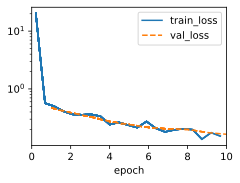

In [14]:
trainer = d2l.Trainer(max_epochs=10)
models = k_fold(trainer, data, k=5, lr=0.01)

In [16]:
preds = [model(torch.tensor(data.val.values.astype(float), dtype=torch.float32))
         for model in models]
# Taking exponentiation of predictions in the logarithm scale
ensemble_preds = torch.exp(torch.cat(preds, 1)).mean(1)
submission = pd.DataFrame({'Id':data.raw_val.Id,
                           'SalePrice':ensemble_preds.detach().numpy()})
submission.to_csv('/Users/zouminghao/Desktop/d2l-notes-exercises/data/submission.csv', index=False)

### Improve Scores by tuning the hyperparameters through K-fold cross-validation

In [37]:
class KaggleHouse(d2l.DataModule):
    def __init__(self, batch_size, train=None, val=None):
        super().__init__()
        self.save_hyperparameters()
        if self.train is None:
            # D2l host a copy of the dataset on their own AWS S3 bucket, so we can download it from there.
            # SHA1 hashes are used to verify the integrity of the downloaded files. If the hash of the downloaded file does not match the expected hash, an error will be raised, indicating that the file may be corrupted or tampered with. It can also skip the download if the file already exists and has the correct hash.
            self.raw_train = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_train.csv', self.root,
                sha1_hash='585e9cc93e70b39160e7921475f9bcd7d31219ce'))
            self.raw_val = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_test.csv', self.root,
                sha1_hash='fa19780a7b011d9b009e8bff8e99922a8ee2eb90'))

In [38]:
data = KaggleHouse(batch_size=64)

In [39]:
@d2l.add_to_class(KaggleHouse)
def preprocess(self):
    # Remove the ID and label columns
    label = 'SalePrice'
    features = pd.concat(
        (self.raw_train.drop(columns=['Id', label]),
         self.raw_val.drop(columns=['Id'])))
    # Standardize numerical columns
    numeric_features = features.dtypes[features.dtypes!='object'].index
    features[numeric_features] = features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std()))
    # Replace NAN numerical features by 0
    features[numeric_features] = features[numeric_features].fillna(0)
    # Replace discrete features by one-hot encoding
    features = pd.get_dummies(features, dummy_na=True)
    # Save preprocessed features
    self.train = features[:self.raw_train.shape[0]].copy()
    self.train[label] = self.raw_train[label]
    self.val = features[self.raw_train.shape[0]:].copy()

In [40]:
@d2l.add_to_class(KaggleHouse)
def get_dataloader(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data: return
    get_tensor = lambda x: torch.tensor(x.values.astype(float),
                                      dtype=torch.float32)
    # Logarithm of prices
    tensors = (get_tensor(data.drop(columns=[label])),  # X
               torch.log(get_tensor(data[label])).reshape((-1, 1)))  # Y
    return self.get_tensorloader(tensors, train)

In [41]:
def k_fold_data(data, k):
    rets = []
    fold_size = data.train.shape[0] // k
    for j in range(k):
        idx = range(j * fold_size, (j+1) * fold_size)
        rets.append(KaggleHouse(data.batch_size, data.train.drop(index=idx),
                                data.train.loc[idx]))
    return rets

In [42]:
def k_fold_score(data, k, lr, max_epochs, batch_size):
    # use new batch_size to construct data
    data = KaggleHouse(batch_size=batch_size)
    data.preprocess()

    trainer = d2l.Trainer(max_epochs=max_epochs)
    val_loss = []

    for i, data_fold in enumerate(k_fold_data(data, k)):
        model = d2l.LinearRegression(lr)
        model.board.yscale = 'log'
        model.board.display = False
        trainer.fit(model, data_fold)
        val_loss.append(float(model.board.data['val_loss'][-1].y))

    avg_val_loss = sum(val_loss) / len(val_loss)
    return avg_val_loss

In [43]:
def hyperparameter_search(k=5):
    lr_candidates = [0.001, 0.003, 0.01, 0.03, 0.1]
    epoch_candidates = [10, 30, 50, 100]
    batch_size_candidates = [32, 64, 128, 256]

    results = []

    for lr, max_epochs, batch_size in itertools.product(
        lr_candidates, epoch_candidates, batch_size_candidates
    ):
        print(f"Testing lr={lr}, max_epochs={max_epochs}, batch_size={batch_size}")
        avg_val_loss = k_fold_score(
            data=None,
            k=k,
            lr=lr,
            max_epochs=max_epochs,
            batch_size=batch_size
        )
        print(f"  -> avg validation log mse = {avg_val_loss:.5f}")

        results.append({
            'lr': lr,
            'max_epochs': max_epochs,
            'batch_size': batch_size,
            'avg_val_log_mse': avg_val_loss
        })

    results_df = pd.DataFrame(results).sort_values('avg_val_log_mse')
    return results_df

In [ ]:
results_df = hyperparameter_search(k=5)

Testing lr=0.001, max_epochs=10, batch_size=32
  -> avg validation log mse = 0.41072
Testing lr=0.001, max_epochs=10, batch_size=64
  -> avg validation log mse = 0.48282
Testing lr=0.001, max_epochs=10, batch_size=128
  -> avg validation log mse = 0.52227
Testing lr=0.001, max_epochs=10, batch_size=256
  -> avg validation log mse = 0.95933
Testing lr=0.001, max_epochs=30, batch_size=32
  -> avg validation log mse = 0.23546
Testing lr=0.001, max_epochs=30, batch_size=64
  -> avg validation log mse = 0.32652
Testing lr=0.001, max_epochs=30, batch_size=128
  -> avg validation log mse = 0.40056
Testing lr=0.001, max_epochs=30, batch_size=256
  -> avg validation log mse = 0.45865
Testing lr=0.001, max_epochs=50, batch_size=32
  -> avg validation log mse = 0.18415
Testing lr=0.001, max_epochs=50, batch_size=64
  -> avg validation log mse = 0.25469
Testing lr=0.001, max_epochs=50, batch_size=128
  -> avg validation log mse = 0.34897
Testing lr=0.001, max_epochs=50, batch_size=256
  -> avg val

In [45]:
print(results_df.head(10))

      lr  max_epochs  batch_size  avg_val_log_mse
61  0.03         100          64         0.031829
60  0.03         100          32         0.032627
62  0.03         100         128         0.040167
44  0.01         100          32         0.040515
57  0.03          50          64         0.042679
45  0.01         100          64         0.046537
63  0.03         100         256         0.051588
52  0.03          30          32         0.052288
53  0.03          30          64         0.052648
40  0.01          50          32         0.053091


average validation log mse = 0.06886456981301307


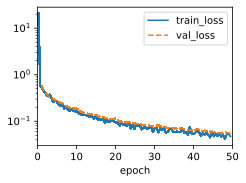

In [46]:
best_lr = 0.01
best_max_epochs = 50
best_batch_size = 64

data = KaggleHouse(batch_size=best_batch_size)
data.preprocess()

trainer = d2l.Trainer(max_epochs=best_max_epochs)
models = k_fold(trainer, data, k=5, lr=best_lr)

preds = [model(torch.tensor(data.val.values.astype(float), dtype=torch.float32))
         for model in models]
ensemble_preds = torch.exp(torch.cat(preds, 1)).mean(1)

submission = pd.DataFrame({
    'Id': data.raw_val.Id,
    'SalePrice': ensemble_preds.detach().numpy()
})
submission.to_csv('/Users/zouminghao/Desktop/d2l-notes-exercises/data/submission_1stHyperParameters.csv', index=False)

### Improve the score by improving the model (e.g., layers, weight decay, and dropout).

In [81]:
class KaggleMLP(d2l.Module):
    def __init__(self, lr, num_features, hidden_dims, dropout=0.0, wd=0.0):
        super().__init__()
        self.save_hyperparameters()

        layers = []
        in_dim = num_features

        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

        self.net.apply(self.init_weights)

    def init_weights(self, m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)

    def forward(self, X):
        return self.net(X)

    def loss(self, y_hat, y):
        return nn.MSELoss()(y_hat, y)

    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l

    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(),
                                lr=self.lr,
                                weight_decay=self.wd)

In [82]:
class KaggleHouse(d2l.DataModule):
    def __init__(self, batch_size, train=None, val=None):
        super().__init__()
        self.save_hyperparameters()
        if self.train is None:
            # D2l host a copy of the dataset on their own AWS S3 bucket, so we can download it from there.
            # SHA1 hashes are used to verify the integrity of the downloaded files. If the hash of the downloaded file does not match the expected hash, an error will be raised, indicating that the file may be corrupted or tampered with. It can also skip the download if the file already exists and has the correct hash.
            self.raw_train = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_train.csv', self.root,
                sha1_hash='585e9cc93e70b39160e7921475f9bcd7d31219ce'))
            self.raw_val = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_test.csv', self.root,
                sha1_hash='fa19780a7b011d9b009e8bff8e99922a8ee2eb90'))

In [83]:
@d2l.add_to_class(KaggleHouse)
def preprocess(self):
    # Remove the ID and label columns
    label = 'SalePrice'
    features = pd.concat(
        (self.raw_train.drop(columns=['Id', label]),
         self.raw_val.drop(columns=['Id'])))
    # Standardize numerical columns
    numeric_features = features.dtypes[features.dtypes!='object'].index
    features[numeric_features] = features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std()))
    # Replace NAN numerical features by 0
    features[numeric_features] = features[numeric_features].fillna(0)
    # Replace discrete features by one-hot encoding
    features = pd.get_dummies(features, dummy_na=True)
    # Save preprocessed features
    self.train = features[:self.raw_train.shape[0]].copy()
    self.train[label] = self.raw_train[label]
    self.val = features[self.raw_train.shape[0]:].copy()

In [84]:
@d2l.add_to_class(KaggleHouse)
def get_dataloader(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data: return
    get_tensor = lambda x: torch.tensor(x.values.astype(float),
                                      dtype=torch.float32)
    # Logarithm of prices
    tensors = (get_tensor(data.drop(columns=[label])),  # X
               torch.log(get_tensor(data[label])).reshape((-1, 1)))  # Y
    return self.get_tensorloader(tensors, train)

In [85]:
def k_fold_score_mlp(k, lr, max_epochs, batch_size,
                     hidden_dims, wd=0.0, dropout=0.0):
    data = KaggleHouse(batch_size=batch_size)
    data.preprocess()

    trainer = d2l.Trainer(max_epochs=max_epochs)
    val_loss = []

    num_features = data.train.drop(columns=['SalePrice']).shape[1]

    for i, data_fold in enumerate(k_fold_data(data, k)):
        model = KaggleMLP(
            lr=lr,
            num_features=num_features,
            hidden_dims=hidden_dims,
            dropout=dropout,
            wd=wd
        )
        model.board.yscale = 'log'
        model.board.display = False
        trainer.fit(model, data_fold)
        val_loss.append(float(model.board.data['val_loss'][-1].y))

    return sum(val_loss) / len(val_loss)

In [86]:
def make_submission(data, models, save_path):
    X_test = torch.tensor(data.val.values.astype(float), dtype=torch.float32)
    preds = [model(X_test) for model in models]
    ensemble_preds = torch.exp(torch.cat(preds, dim=1)).mean(dim=1)

    submission = pd.DataFrame({
        'Id': data.raw_val.Id,
        'SalePrice': ensemble_preds.detach().numpy()
    })
    submission.to_csv(save_path, index=False)
    return submission

In [87]:
def search_architecture(k=5):
    lr = 0.01
    max_epochs = 50
    batch_size = 64

    hidden_dims_candidates = [
        [64],
        [128],
        [64, 32],
        [128, 64],
        [256, 128, 64]
    ]
    wd_candidates = [0.0, 1e-5, 1e-4, 1e-3]
    dropout_candidates = [0.0, 0.1, 0.2, 0.3]

    results = []

    for hidden_dims, wd, dropout in itertools.product(
        hidden_dims_candidates, wd_candidates, dropout_candidates
    ):
        print(f"Testing hidden_dims={hidden_dims}, wd={wd}, dropout={dropout}")

        avg_val_loss = k_fold_score_mlp(
            k=k,
            lr=lr,
            max_epochs=max_epochs,
            batch_size=batch_size,
            hidden_dims=hidden_dims,
            wd=wd,
            dropout=dropout
        )

        print(f"avg validation log mse = {avg_val_loss:.5f}")
        
        results.append({
            'hidden_dims': str(hidden_dims),
            'wd': wd,
            'dropout': dropout,
            'avg_val_log_mse': avg_val_loss
        })

    return pd.DataFrame(results).sort_values('avg_val_log_mse').reset_index(drop=True)

In [88]:
results_df_arch = search_architecture(k=5)

Testing hidden_dims=[64], wd=0.0, dropout=0.0
avg validation log mse = 0.03945
Testing hidden_dims=[64], wd=0.0, dropout=0.1
avg validation log mse = 0.17660
Testing hidden_dims=[64], wd=0.0, dropout=0.2
avg validation log mse = 0.13393
Testing hidden_dims=[64], wd=0.0, dropout=0.3
avg validation log mse = 0.24198
Testing hidden_dims=[64], wd=1e-05, dropout=0.0
avg validation log mse = 0.04389
Testing hidden_dims=[64], wd=1e-05, dropout=0.1
avg validation log mse = 0.08242
Testing hidden_dims=[64], wd=1e-05, dropout=0.2
avg validation log mse = 0.22575
Testing hidden_dims=[64], wd=1e-05, dropout=0.3
avg validation log mse = 0.22038
Testing hidden_dims=[64], wd=0.0001, dropout=0.0
avg validation log mse = 0.04086
Testing hidden_dims=[64], wd=0.0001, dropout=0.1
avg validation log mse = 0.11144
Testing hidden_dims=[64], wd=0.0001, dropout=0.2
avg validation log mse = 0.18108
Testing hidden_dims=[64], wd=0.0001, dropout=0.3
avg validation log mse = 0.16795
Testing hidden_dims=[64], wd=0.0

In [89]:
print(results_df_arch.head(10))

      hidden_dims      wd  dropout  avg_val_log_mse
0           [128]  0.0000      0.0         0.029851
1        [64, 32]  0.0010      0.0         0.033317
2        [64, 32]  0.0000      0.0         0.037929
3            [64]  0.0000      0.0         0.039452
4        [64, 32]  0.0001      0.0         0.039708
5       [128, 64]  0.0010      0.0         0.039736
6           [128]  0.0001      0.0         0.039993
7            [64]  0.0001      0.0         0.040857
8  [256, 128, 64]  0.0000      0.0         0.041770
9            [64]  0.0010      0.0         0.043069


In [91]:
def search_training_params(best_hidden_dims, best_wd, best_dropout, k=5):
    lr_candidates = [1e-4, 3e-4, 1e-3, 3e-3]
    epoch_candidates = [50, 100, 200]
    batch_size_candidates = [32, 64, 128]

    results = []

    for lr, max_epochs, batch_size in itertools.product(
        lr_candidates, epoch_candidates, batch_size_candidates
    ):
        print(f"Testing lr={lr}, max_epochs={max_epochs}, batch_size={batch_size}")

        avg_val_loss = k_fold_score_mlp(
            k=k,
            lr=lr,
            max_epochs=max_epochs,
            batch_size=batch_size,
            hidden_dims=best_hidden_dims,
            wd=best_wd,
            dropout=best_dropout
        )

        print(f"avg validation log mse = {avg_val_loss:.5f}")
        
        results.append({
            'lr': lr,
            'max_epochs': max_epochs,
            'batch_size': batch_size,
            'avg_val_log_mse': avg_val_loss
        })

    return pd.DataFrame(results).sort_values('avg_val_log_mse').reset_index(drop=True)

In [92]:
results_df_trainParams = search_training_params(best_hidden_dims=[64, 32], best_wd=1e-3, best_dropout=0.0, k=5)

Testing lr=0.0001, max_epochs=50, batch_size=32
avg validation log mse = 0.11377
Testing lr=0.0001, max_epochs=50, batch_size=64
avg validation log mse = 0.18008
Testing lr=0.0001, max_epochs=50, batch_size=128
avg validation log mse = 0.29444
Testing lr=0.0001, max_epochs=100, batch_size=32
avg validation log mse = 0.05186
Testing lr=0.0001, max_epochs=100, batch_size=64
avg validation log mse = 0.09961
Testing lr=0.0001, max_epochs=100, batch_size=128
avg validation log mse = 0.18285
Testing lr=0.0001, max_epochs=200, batch_size=32
avg validation log mse = 0.02852
Testing lr=0.0001, max_epochs=200, batch_size=64
avg validation log mse = 0.04791
Testing lr=0.0001, max_epochs=200, batch_size=128
avg validation log mse = 0.07155
Testing lr=0.0003, max_epochs=50, batch_size=32
avg validation log mse = 0.03972
Testing lr=0.0003, max_epochs=50, batch_size=64
avg validation log mse = 0.06856
Testing lr=0.0003, max_epochs=50, batch_size=128
avg validation log mse = 0.11969
Testing lr=0.0003,

In [93]:
print(results_df_trainParams.head(10))

       lr  max_epochs  batch_size  avg_val_log_mse
0  0.0010         200         128         0.026575
1  0.0030          50          64         0.027133
2  0.0003         200          32         0.028122
3  0.0010         100          64         0.028389
4  0.0001         200          32         0.028516
5  0.0030         100          64         0.029361
6  0.0030         100         128         0.029904
7  0.0010         200          64         0.030488
8  0.0010         200          32         0.031703
9  0.0010         100         128         0.032530


In [94]:
def k_fold_train_mlp(k, lr, max_epochs, batch_size,
                     hidden_dims, wd=0.0, dropout=0.0):
    data = KaggleHouse(batch_size=batch_size)
    data.preprocess()

    trainer = d2l.Trainer(max_epochs=max_epochs)
    models = []
    val_loss = []

    num_features = data.train.drop(columns=['SalePrice']).shape[1]

    for i, data_fold in enumerate(k_fold_data(data, k)):
        model = KaggleMLP(
            lr=lr,
            num_features=num_features,
            hidden_dims=hidden_dims,
            dropout=dropout,
            wd=wd
        )
        model.board.yscale = 'log'
        model.board.display = False
        trainer.fit(model, data_fold)
        val_loss.append(float(model.board.data['val_loss'][-1].y))
        models.append(model)

    print(f'average validation log mse = {sum(val_loss)/len(val_loss)}')
    return data, models

In [95]:
best_lr = 1e-3
best_max_epochs = 200
best_batch_size = 128
best_hidden_dims = [64, 32]
best_wd = 1e-3
best_dropout = 0.0

data, models = k_fold_train_mlp(
    k=5,
    lr=best_lr,
    max_epochs=best_max_epochs,
    batch_size=best_batch_size,
    hidden_dims=best_hidden_dims,
    wd=best_wd,
    dropout=best_dropout
)

submission = make_submission(
    data,
    models,
    '/Users/zouminghao/Desktop/d2l-notes-exercises/data/submission_mlp.csv'
)

average validation log mse = 0.029866342432796955
